## import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

## Data Preparation

In [3]:
data=pd.read_csv(r"/content/car_sales_2018_2024_enhanced.csv")

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127474 entries, 0 to 127473
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Date               127474 non-null  object 
 1   Salesperson        127474 non-null  object 
 2   Customer Name      127474 non-null  object 
 3   Customer Age       127474 non-null  int64  
 4   Customer Gender    127474 non-null  object 
 5   Car Make           127474 non-null  object 
 6   Car Model          127474 non-null  object 
 7   Car Year           127474 non-null  int64  
 8   Quantity           127473 non-null  float64
 9   Sale Price         127473 non-null  float64
 10  Cost               127473 non-null  float64
 11  Profit             127473 non-null  float64
 12  Discount           127473 non-null  float64
 13  Payment Method     127473 non-null  object 
 14  Commission Rate    127473 non-null  float64
 15  Commission Earned  127473 non-null  float64
 16  Sa

In [5]:
data.columns

Index(['Date', 'Salesperson', 'Customer Name', 'Customer Age',
       'Customer Gender', 'Car Make', 'Car Model', 'Car Year', 'Quantity',
       'Sale Price', 'Cost', 'Profit', 'Discount', 'Payment Method',
       'Commission Rate', 'Commission Earned', 'Sales Region', 'Sale Year',
       'Sale Month', 'Sale Quarter', 'Day of Week', 'Season'],
      dtype='object')

In [6]:
data.isna().sum()

,0
Date,0
Salesperson,0
Customer Name,0
Customer Age,0
Customer Gender,0
Car Make,0
Car Model,0
Car Year,0
Quantity,1
Sale Price,1


In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data.dtypes

,0
Date,object
Salesperson,object
Customer Name,object
Customer Age,int64
Customer Gender,object
Car Make,object
Car Model,object
Car Year,int64
Quantity,float64
Sale Price,float64


#### data cleaning

In [9]:
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

numeric_cols = ['Customer Age', 'Car Year', 'Quantity', 'Sale Price',
                'Cost', 'Profit', 'Discount', 'Commission Rate',
                'Sale Year', 'Sale Quarter']
data[numeric_cols] = data[numeric_cols].apply(pd.to_numeric, errors='coerce')

categorical_cols = ['Salesperson', 'Customer Gender', 'Car Make',
                    'Car Model', 'Payment Method', 'Sales Region',
                    'Sale Month', 'Day of Week', 'Season']
for col in categorical_cols:
    data[col] = data[col].astype('category')


data = data.drop(columns=['Customer Name', 'Commission Earned'])

data = data.dropna(subset=['Sale Price', 'Date'])
data = data.fillna(method='ffill')
data = data.sort_values('Date').reset_index(drop=True)



## EDA

In [10]:
data.select_dtypes("number").columns

Index(['Customer Age', 'Car Year', 'Quantity', 'Sale Price', 'Cost', 'Profit',
       'Discount', 'Commission Rate', 'Sale Year', 'Sale Quarter'],
      dtype='object')

In [11]:
num_features = [
    'Customer Age', 'Car Year', 'Quantity', 'Sale Price',
    'Cost', 'Profit', 'Discount', 'Commission Rate',
    'Sale Year', 'Sale Quarter'
]


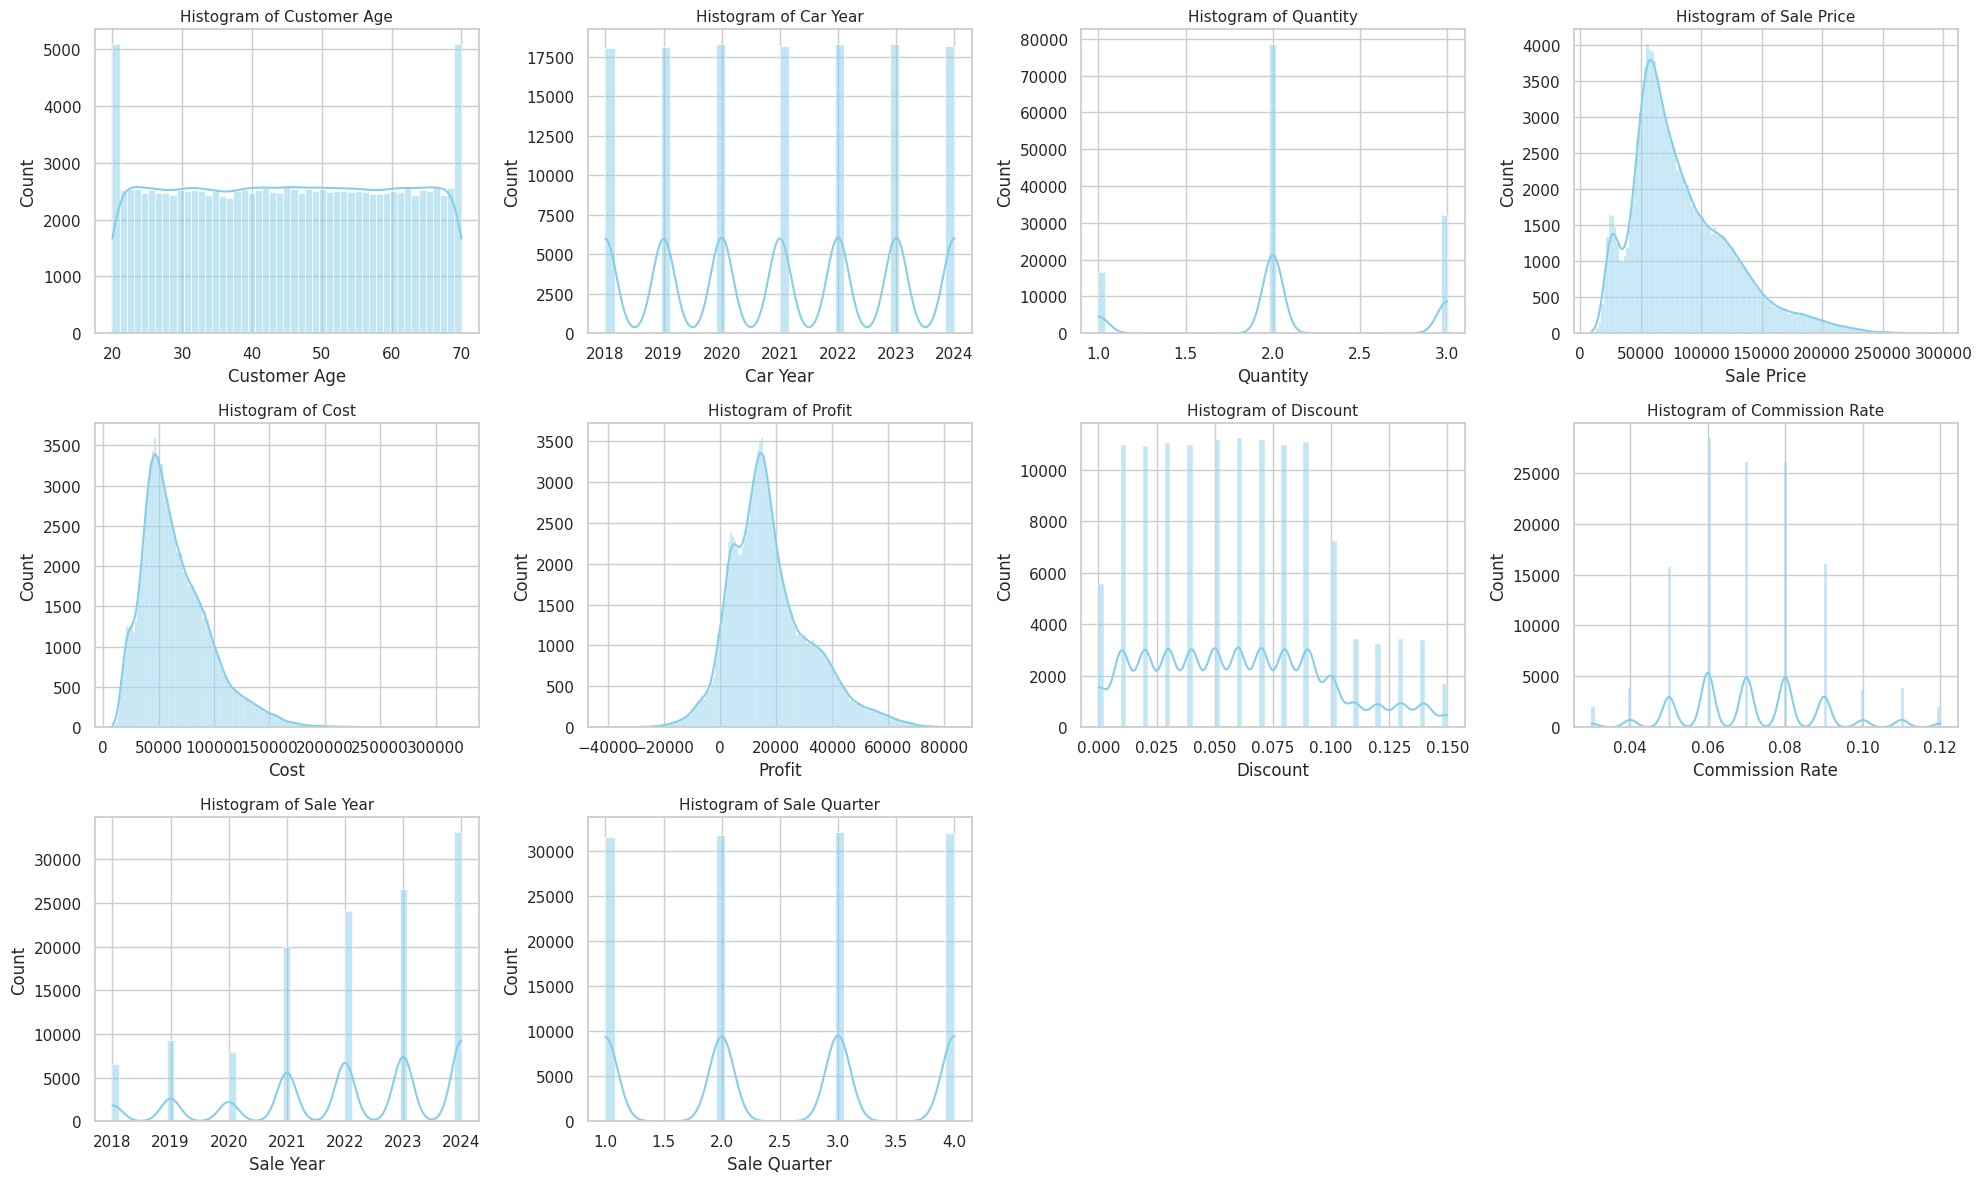

In [12]:


sns.set(style="whitegrid")

fig, axes = plt.subplots(3, 4, figsize=(20, 12))

for i, col in enumerate(num_features):
    ax = axes[i // 4, i % 4]
    sns.histplot(data[col], color="skyblue", kde=True, ax=ax)
    ax.set_title(f"Histogram of {col}", fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

for j in range(len(num_features), 12):
    fig.delaxes(axes[j // 4, j % 4])

plt.tight_layout()
plt.show()



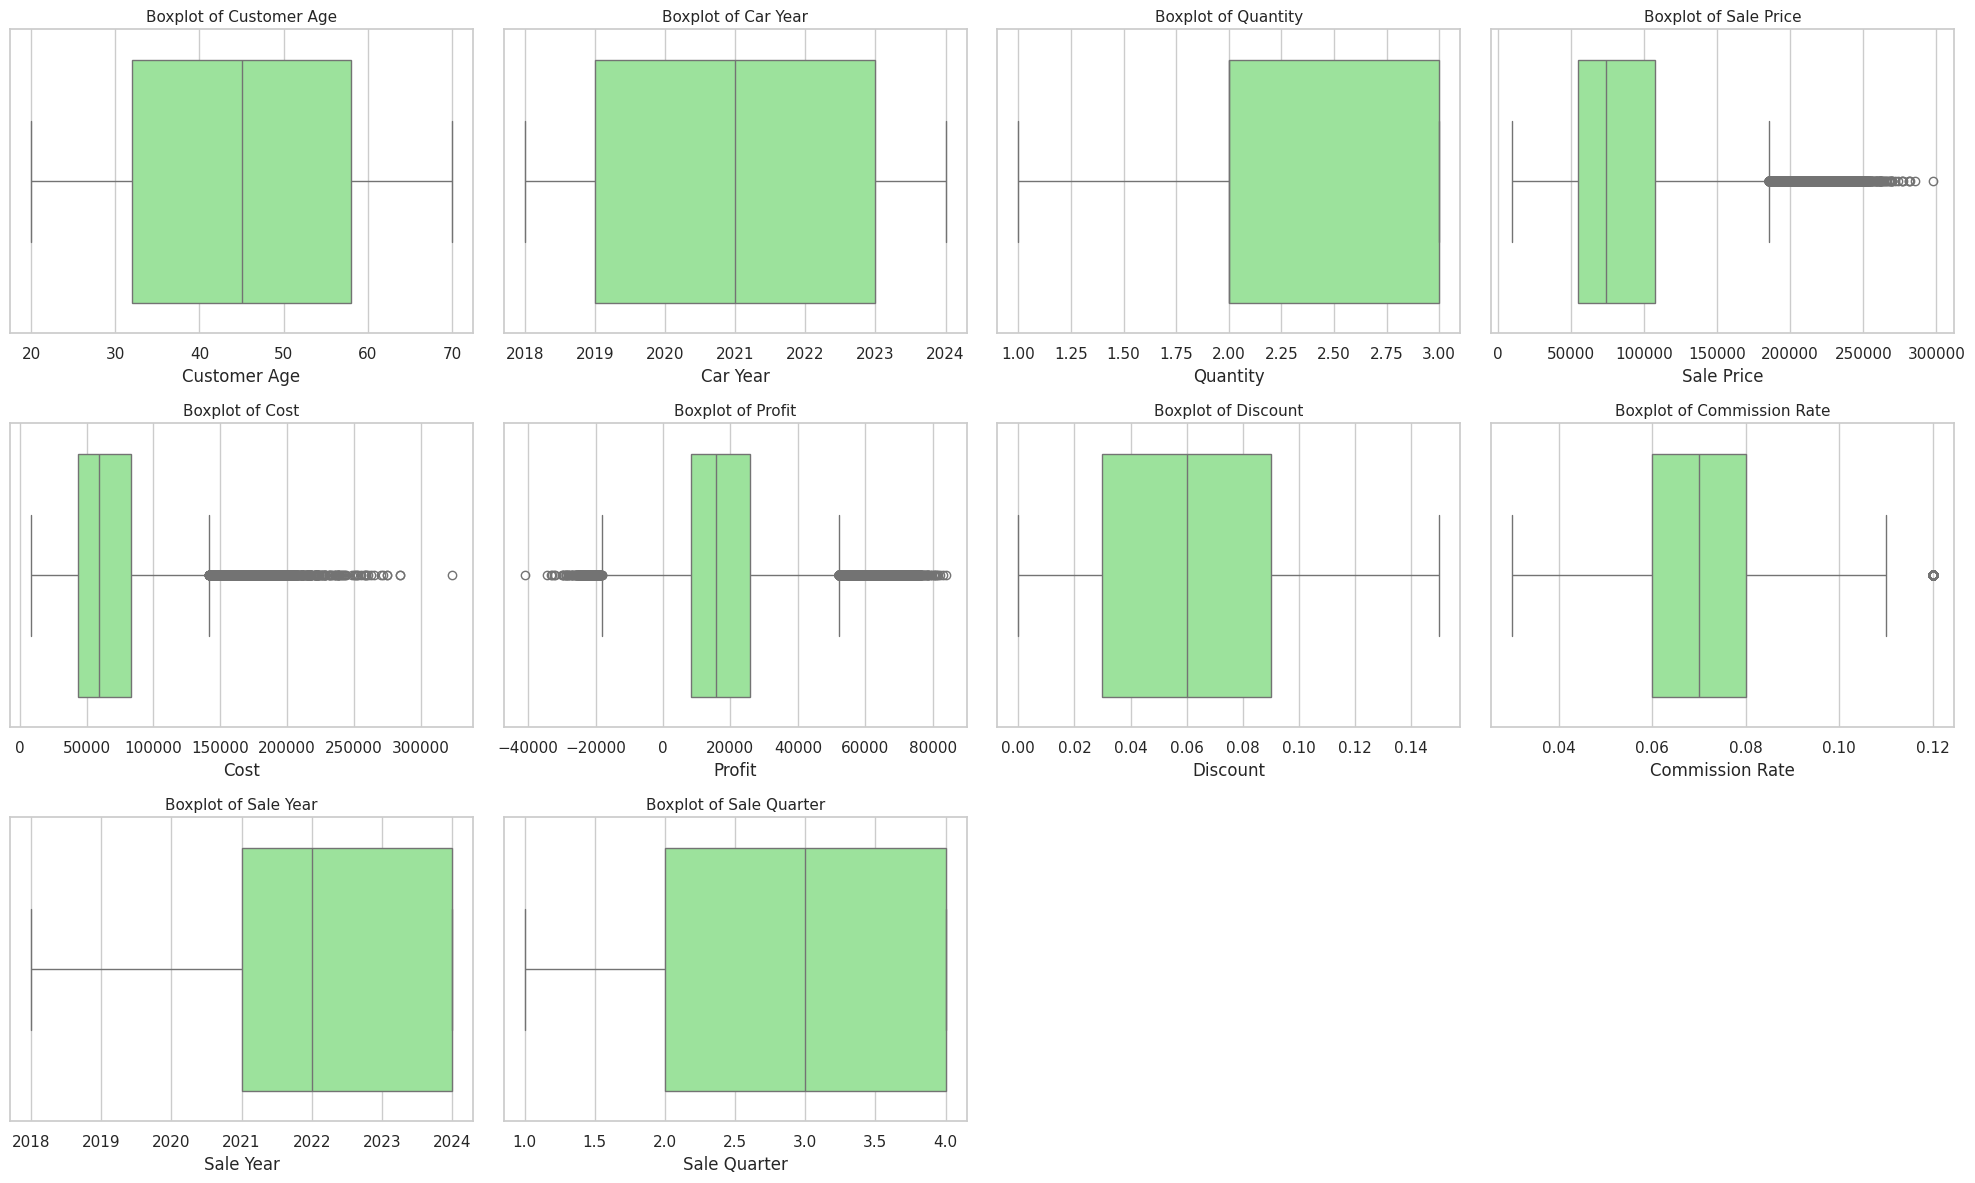

In [13]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))

for i, col in enumerate(num_features):
    ax = axes[i // 4, i % 4]
    sns.boxplot(x=data[col], color="lightgreen", ax=ax)
    ax.set_title(f"Boxplot of {col}", fontsize=11)
    ax.set_xlabel(col)

# Hide unused axes
for j in range(len(num_features), 12):
    fig.delaxes(axes[j // 4, j % 4])

plt.tight_layout()
plt.show()


## Feature engineering

In [14]:

data['Date'] = pd.to_datetime(data['Date'])
data['Sale_Day'] = data['Date'].dt.day
data['Sale_Week'] = data['Date'].dt.isocalendar().week
data['Sale_Weekday'] = data['Date'].dt.weekday
data['Is_Weekend'] = data['Sale_Weekday'].isin([5,6]).astype(int)
data['Cumulative_Quantity_Model'] = data.groupby('Car Model')['Quantity'].cumsum()


## analysis after feature engineering

#### Correlation and Multicollinearity

<Axes: xlabel='Car Make', ylabel='Sale Price'>

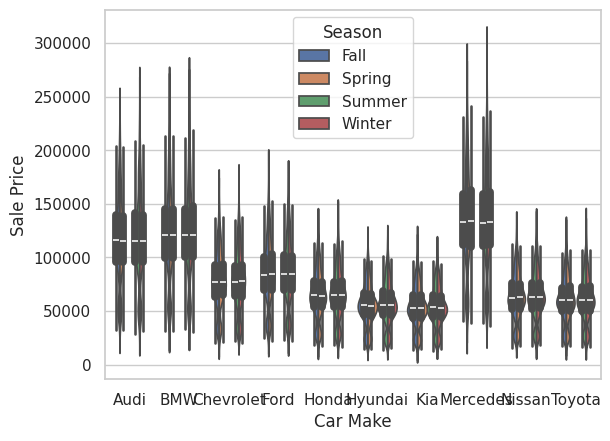

In [15]:
sns.violinplot(x='Car Make', y='Sale Price', hue='Season', data=data, split=True)


In [16]:
!pip install statsmodels


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 122.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 20.1 MB/s eta 0:00:00


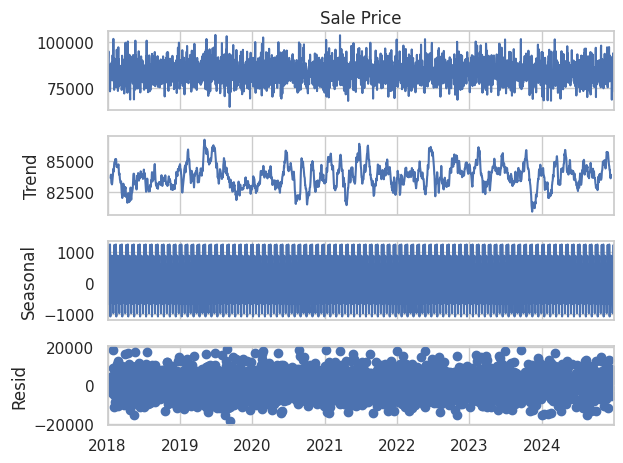

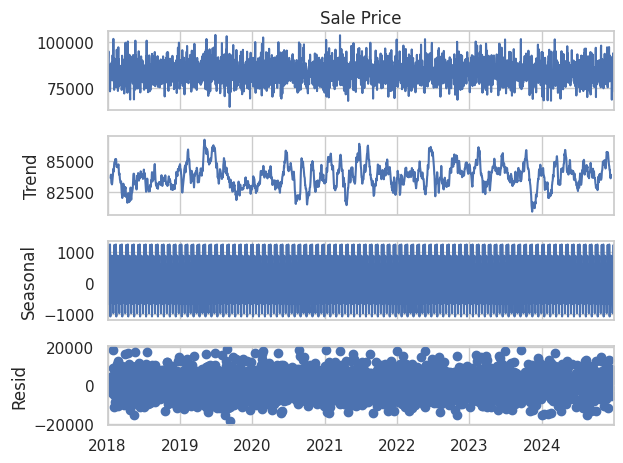

In [17]:
import statsmodels.api as sm

ts = data.groupby('Date')['Sale Price'].mean()
decomposition = sm.tsa.seasonal_decompose(ts, model='additive', period=30)
decomposition.plot()


In [ ]:
### seasonality analysis

In [18]:
data = data.sort_values('Date')


dates = data['Date'].reset_index(drop=True)

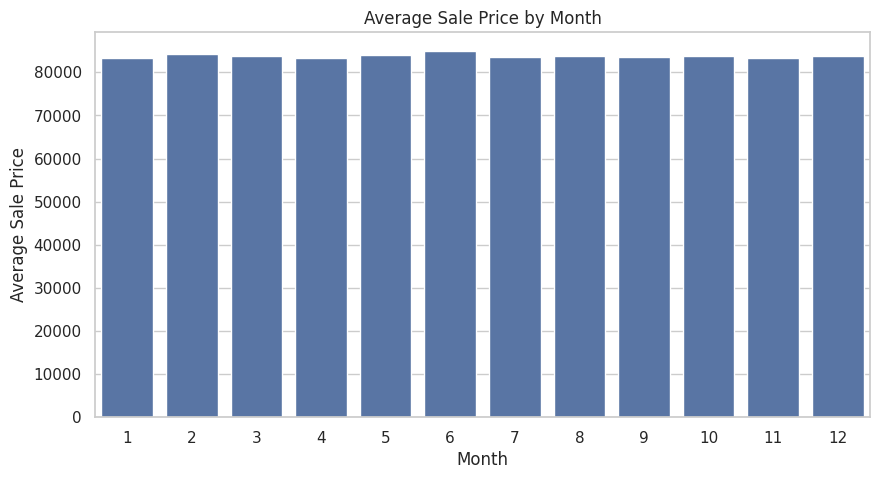

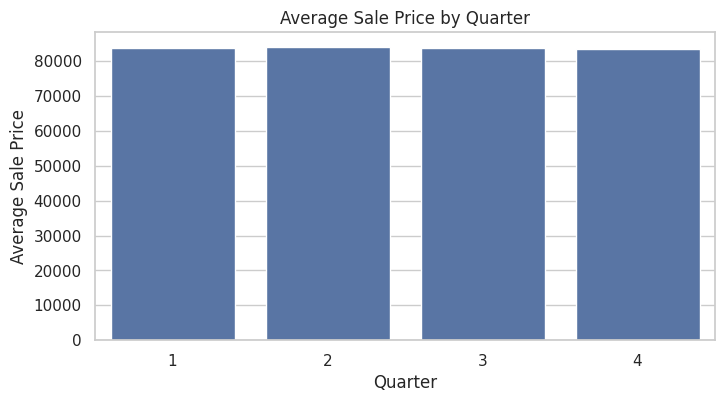

In [19]:
# Monthly seasonality
monthly_avg = data.groupby(data['Date'].dt.month)['Sale Price'].mean()
plt.figure(figsize=(10,5))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values)
plt.title('Average Sale Price by Month')
plt.xlabel('Month')
plt.ylabel('Average Sale Price')
plt.show()

# Quarterly seasonality
quarterly_avg = data.groupby(data['Date'].dt.quarter)['Sale Price'].mean()
plt.figure(figsize=(8,4))
sns.barplot(x=quarterly_avg.index, y=quarterly_avg.values)
plt.title('Average Sale Price by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Average Sale Price')
plt.show()


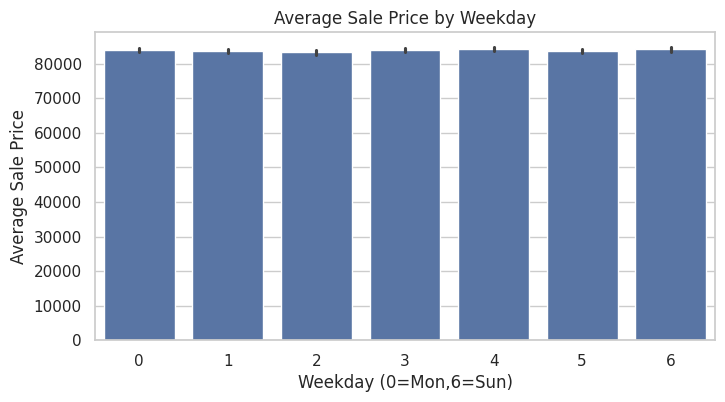

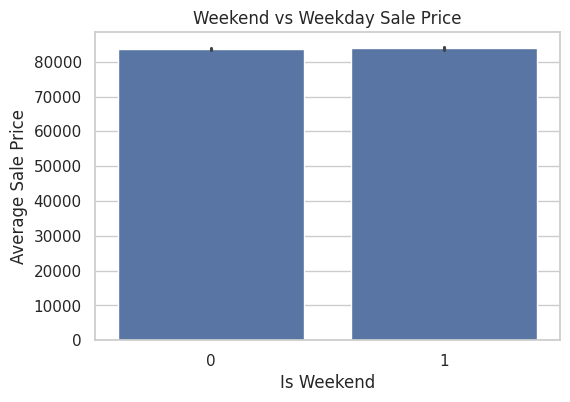

In [20]:
data['Weekday'] = data['Date'].dt.weekday
data['Is_Weekend'] = data['Weekday'].isin([5,6]).astype(int)

plt.figure(figsize=(8,4))
sns.barplot(x='Weekday', y='Sale Price', data=data)
plt.title('Average Sale Price by Weekday')
plt.xlabel('Weekday (0=Mon,6=Sun)')
plt.ylabel('Average Sale Price')
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(x='Is_Weekend', y='Sale Price', data=data)
plt.title('Weekend vs Weekday Sale Price')
plt.xlabel('Is Weekend')
plt.ylabel('Average Sale Price')
plt.show()


In [ ]:
#### . Seasonal Decomposition

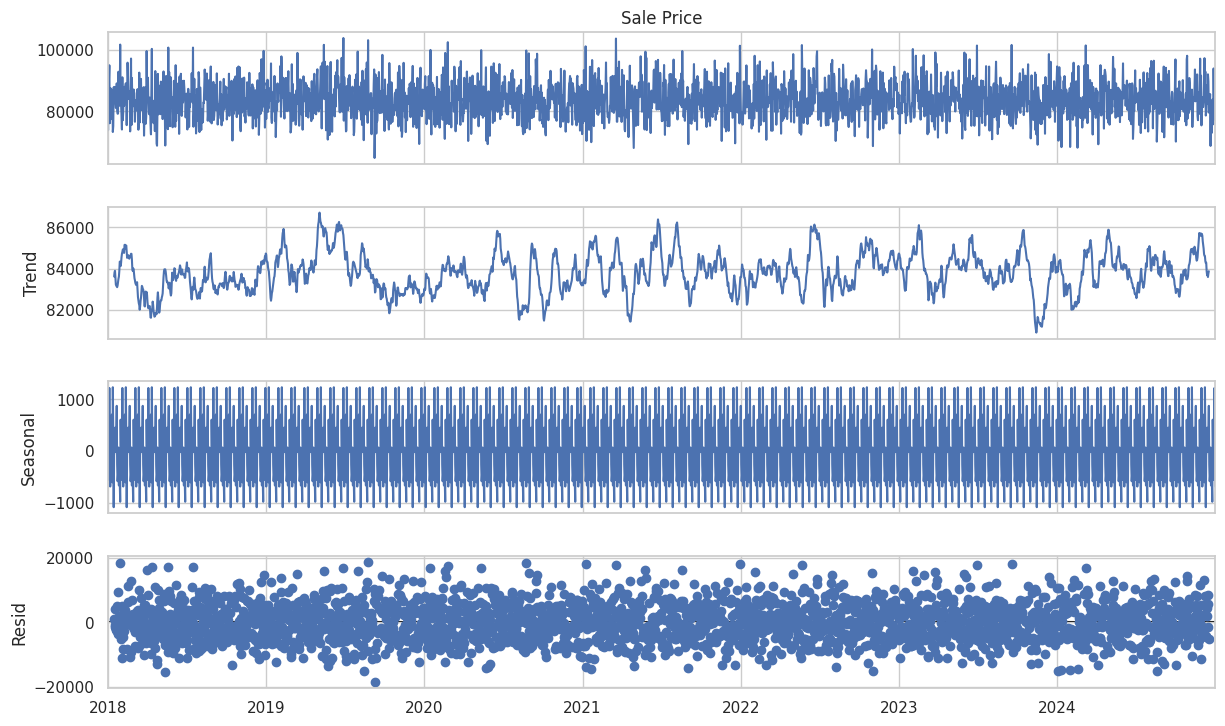

In [21]:
data['Date'] = pd.to_datetime(data['Date'])

# Daily aggregation
ts = data.groupby('Date')['Sale Price'].mean()

# Seasonal decomposition
decomposition = sm.tsa.seasonal_decompose(ts, model='additive', period=30)
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.show()



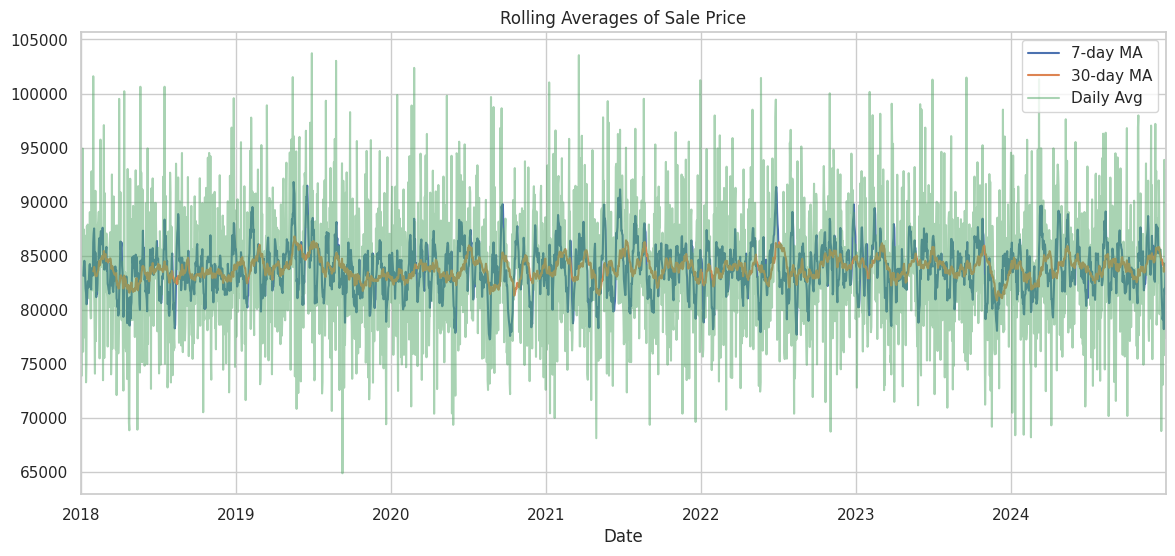

In [22]:
plt.figure(figsize=(14,6))
ts.rolling(window=7).mean().plot(label='7-day MA')
ts.rolling(window=30).mean().plot(label='30-day MA')
ts.plot(alpha=0.5, label='Daily Avg')
plt.title('Rolling Averages of Sale Price')
plt.legend()
plt.show()


In [23]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
# Drop columns to avoid leakage
X = data[numeric_cols].drop(columns=['Cost','Profit','Sale Price'])

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)



                     feature            VIF
0               Customer Age      10.313229
1                   Car Year  641756.211419
2                   Quantity      14.837101
3                   Discount       3.574772
4            Commission Rate      17.599689
5                  Sale Year  643718.258509
6               Sale Quarter       6.148448
7                 Is_Weekend       1.403432
8  Cumulative_Quantity_Model       4.070856


## Data Preprocesing

In [ ]:
data.columns

In [24]:

drop_cols = ['Cost', 'Profit', 'Sale Price', 'Car Year', 'Customer Age']
X = data.drop(columns=drop_cols)
y = data['Sale Price']
dates = data['Date']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [25]:
numeric_features = [
    'Quantity',
    'Discount',
    'Commission Rate',
    'Sale Month',
    'Sale_Day',
    'Sale_Week',
    'Sale_Weekday',
    'Is_Weekend',
    'Cumulative_Quantity_Model',
    'Weekday'
]


In [26]:
nominal_features = [
    'Salesperson',
    'Customer Gender',
    'Car Make',
    'Car Model',
    'Payment Method',
    'Sales Region',
    'Season',
    'Day of Week'
]


In [27]:
ordinal_features = [
    'Sale Quarter'
]


In [28]:

numeric_features = ['Quantity', 'Discount', 'Commission Rate', 'Sale Month',
                    'Sale_Day', 'Sale_Week', 'Sale_Weekday', 'Is_Weekend',
                    'Cumulative_Quantity_Model', 'Weekday']

for col in numeric_features:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')


In [29]:


numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('nom', nominal_transformer, nominal_features),
    ('ord', ordinal_transformer, ordinal_features)
])


In [30]:
# Fit only on training set
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test set
X_test_processed = preprocessor.transform(X_test)

print("X_train shape:", X_train_processed.shape)
print("X_test shape:", X_test_processed.shape)


X_train shape: (101978, 186)
X_test shape: (25495, 186)


## Model Building

In [ ]:
#### Define Sequence Creation Function

In [31]:
# -----------------------------
def create_sequences(X, y, seq_length=4):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

In [32]:



_, dates_test = train_test_split(
    dates, test_size=0.2, random_state=42, shuffle=False
)


X_train_dense = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
X_test_dense  = X_test_processed.toarray()  if hasattr(X_test_processed, "toarray") else X_test_processed

# Now create sequences
seq_length = 100
X_train_seq, y_train_seq = create_sequences(X_train_dense, y_train.values, seq_length)
X_test_seq, y_test_seq = create_sequences(X_test_dense, y_test.values, seq_length)

# Dates corresponding to test sequences (skip first `seq_length` rows)
dates_test_seq = dates_test[seq_length:].reset_index(drop=True)

print(len(dates_test_seq), len(y_test_seq))

25395 25395


In [33]:
print("X_train_seq shape:", X_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("Dates_test_seq length:", len(dates_test_seq), "should match y_test_seq length:", len(y_test_seq))

X_train_seq shape: (101878, 100, 186)
X_test_seq shape: (25395, 100, 186)
Dates_test_seq length: 25395 should match y_test_seq length: 25395


In [34]:
! pip install tensorflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 905.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 116.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 106.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.4 MB/s eta 0:00:00


In [35]:


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam

model = Sequential([

    LSTM(128, activation='tanh', return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.3),


    LSTM(64, activation='tanh', return_sequences=False),
    Dropout(0.3),


    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),


    Dense(1, activation='linear')
])















In [36]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 128)       │       161,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 216,961 (847.50 KB)

 Trainable params: 216,961 (847.50 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
history = model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=10,
    batch_size=256,
    verbose=1
)

Epoch 1/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 149s 397ms/step - loss: 8518490624.0000 - mae: 82496.1484 - val_loss: 5590427136.0000 - val_mae: 62687.3906
Epoch 2/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 140s 390ms/step - loss: 3919409920.0000 - mae: 48579.6758 - val_loss: 1678247168.0000 - val_mae: 31674.1230
Epoch 3/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 140s 390ms/step - loss: 1781654528.0000 - mae: 32801.0859 - val_loss: 1666930944.0000 - val_mae: 32010.7480
Epoch 4/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 141s 393ms/step - loss: 1780237696.0000 - mae: 32938.9844 - val_loss: 1666664576.0000 - val_mae: 32031.1367
Epoch 5/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 141s 394ms/step - loss: 1791666304.0000 - mae: 33140.7539 - val_loss: 1668300800.0000 - val_mae: 31931.7793
Epoch 6/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 139s 388ms/step - loss: 1774287360.0000 - mae: 32784.9805 - val_loss: 1667313280.0000 - val_mae: 31985.1875
Epoch 7/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 139s 386ms/step - loss: 1786755328.0000 - mae: 33059.4531 - val_loss: 16

In [38]:

loss, mae = model.evaluate(X_test_seq, y_test_seq)
print("Test MAE:", mae)

794/794 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - loss: 1733527168.0000 - mae: 32623.8340
Test MAE: 32212.509765625


In [39]:
y_pred = model.predict(X_test_seq)

794/794 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step


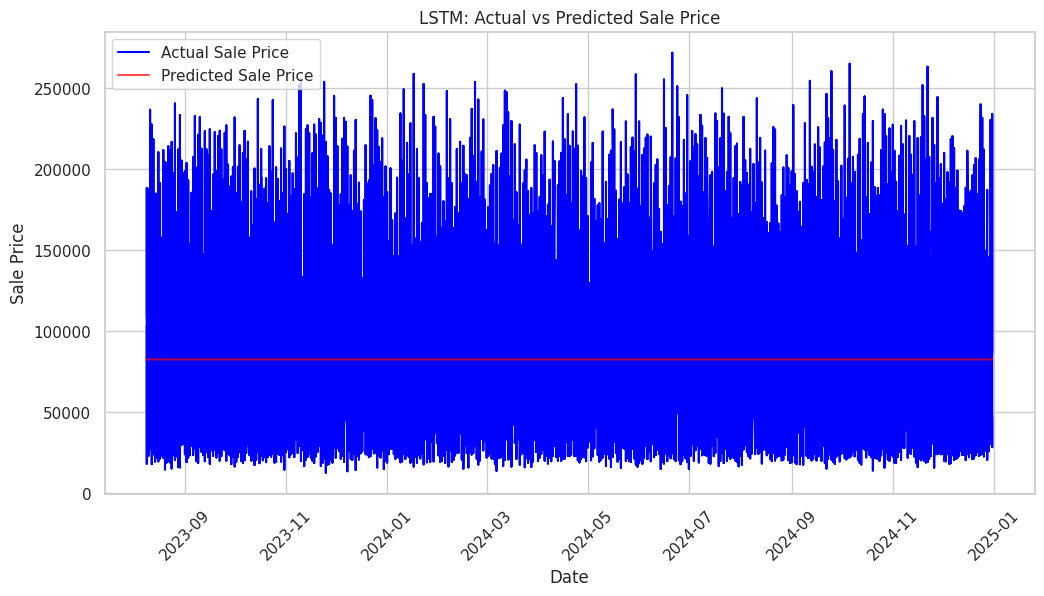

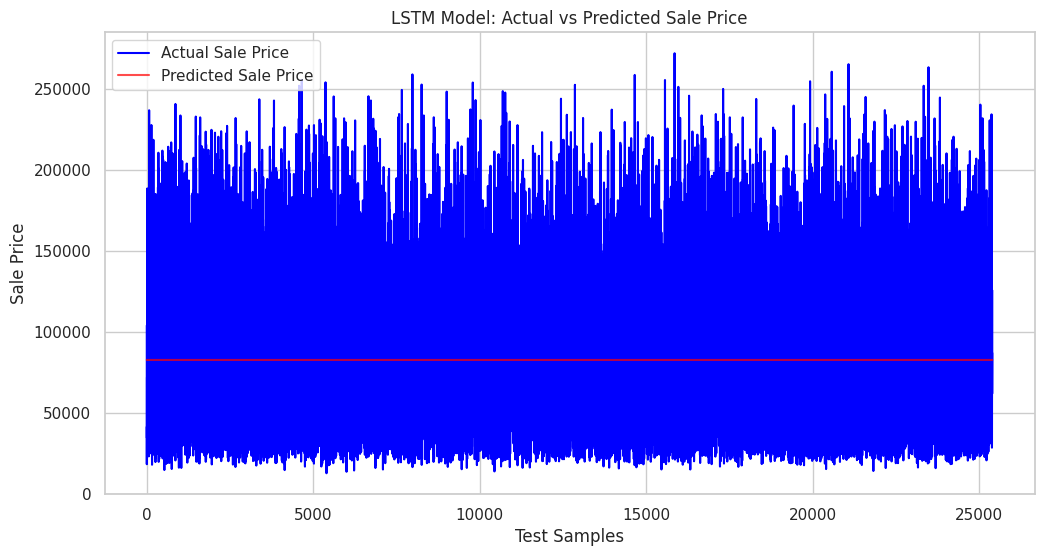

In [40]:

plt.figure(figsize=(12,6))
plt.plot(dates_test_seq, y_test_seq, label='Actual Sale Price', color='blue')
plt.plot(dates_test_seq, y_pred, label='Predicted Sale Price', color='red', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Sale Price')
plt.title('LSTM: Actual vs Predicted Sale Price')
plt.xticks(rotation=45)
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(y_test_seq, label='Actual Sale Price', color='blue')
plt.plot(y_pred, label='Predicted Sale Price', color='red', alpha=0.7)
plt.xlabel('Test Samples')
plt.ylabel('Sale Price')
plt.title('LSTM Model: Actual vs Predicted Sale Price')
plt.legend()
plt.show()

In [41]:
# Step 8: Future Forecasting
# -----------------------------
forecast_horizon = 12  # months ahead

# Last date in dataset
last_date = data['Date'].max()
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=forecast_horizon, freq='MS')

# Generate future features
future_df = pd.DataFrame({'Date': future_dates})
future_df['Sale Month'] = future_df['Date'].dt.month
future_df['Sale_Week'] = future_df['Date'].dt.isocalendar().week
future_df['Sale_Weekday'] = future_df['Date'].dt.weekday
future_df['Is_Weekend'] = future_df['Sale_Weekday'].isin([5,6]).astype(int)
future_df['Sale_Day'] = future_df['Date'].dt.day
future_df['Sale Quarter'] = future_df['Date'].dt.quarter
future_df['Season'] = future_df['Date'].dt.month % 12 // 3 + 1  # 1=winter,2=spring,3=summer,4=fall


In [42]:
# Preprocess future data
X_future_processed = preprocessor.transform(future_df)

# Start forecasting
predictions = []
last_sequence = X_train_seq[-1]  # last sequence from training

for i in range(forecast_horizon):
    pred = model.predict(last_sequence.reshape(1, seq_length, X_train_seq.shape[2]))[0][0]
    predictions.append(pred)

    # Update last_sequence by removing oldest timestep and adding new future step
    new_step = X_future_processed[i].reshape(1, X_train_seq.shape[2])
    last_sequence = np.vstack([last_sequence[1:], new_step])



ValueError: columns are missing: {'Day of Week', 'Commission Rate', 'Sales Region', 'Discount', 'Customer Gender', 'Car Make', 'Cumulative_Quantity_Model', 'Car Model', 'Salesperson', 'Weekday', 'Quantity', 'Payment Method'}

In [ ]:
# Plot future forecast
plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Sale Price'], label='Historical')
plt.plot(future_dates, predictions, label='Forecast', color='red')
plt.xlabel('Date')
plt.ylabel('Sale Price')
plt.title('Sales Forecast for Next Year')
plt.legend()
plt.show()
